# Price and User Ratings

The publisher pricing strategy team wants to examine whether more expensive games receive better user ratings.

Positive review ratio is calculated as:

$$
\frac{\text{positive ratings}}
{\text{positive ratings}+\text{negative ratings}}
$$

Before interpreting the overall correlation, the analysis also considers rating volume. Games with more ratings may differ systematically in both price and review outcomes, so total rating count could influence the observed relationship.

The analysis therefore compares the overall price-rating correlation with the partial correlation after accounting for total rating volume.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr


STEAM_PATH = "../../data/steam/steam.csv"


steam = pd.read_csv(STEAM_PATH)

steam = steam.dropna(
    subset=[
        "price",
        "positive_ratings",
        "negative_ratings",
    ]
).copy()


# Calculate review ratio and rating volume.
steam["total_ratings"] = (
    steam["positive_ratings"]
    + steam["negative_ratings"]
)

steam = steam[
    steam["total_ratings"] > 0
].copy()

steam["positive_ratio"] = (
    steam["positive_ratings"]
    / steam["total_ratings"]
)

steam["log_total_ratings"] = np.log1p(
    steam["total_ratings"]
)


# Overall correlation.
overall_r, overall_p = pearsonr(
    steam["price"],
    steam["positive_ratio"],
)


# Examine rating volume.
price_volume_r, _ = pearsonr(
    steam["price"],
    steam["log_total_ratings"],
)

rating_volume_r, _ = pearsonr(
    steam["positive_ratio"],
    steam["log_total_ratings"],
)


# Remove the linear relationship with rating volume.
price_fit = np.polyfit(
    steam["log_total_ratings"],
    steam["price"],
    1,
)

rating_fit = np.polyfit(
    steam["log_total_ratings"],
    steam["positive_ratio"],
    1,
)

price_resid = (
    steam["price"]
    - np.polyval(
        price_fit,
        steam["log_total_ratings"],
    )
)

rating_resid = (
    steam["positive_ratio"]
    - np.polyval(
        rating_fit,
        steam["log_total_ratings"],
    )
)


# Partial correlation.
partial_r, partial_p = pearsonr(
    price_resid,
    rating_resid,
)


print(
    "Overall correlation:",
    f"{overall_r:.3f}",
)

print(
    "Price vs rating volume:",
    f"{price_volume_r:.3f}",
)

print(
    "Positive ratio vs rating volume:",
    f"{rating_volume_r:.3f}",
)

print(
    "Partial correlation controlling for rating volume:",
    f"{partial_r:.3f}",
)

Overall correlation: 0.076
Price vs rating volume: 0.247
Positive ratio vs rating volume: 0.164
Partial correlation controlling for rating volume: 0.038


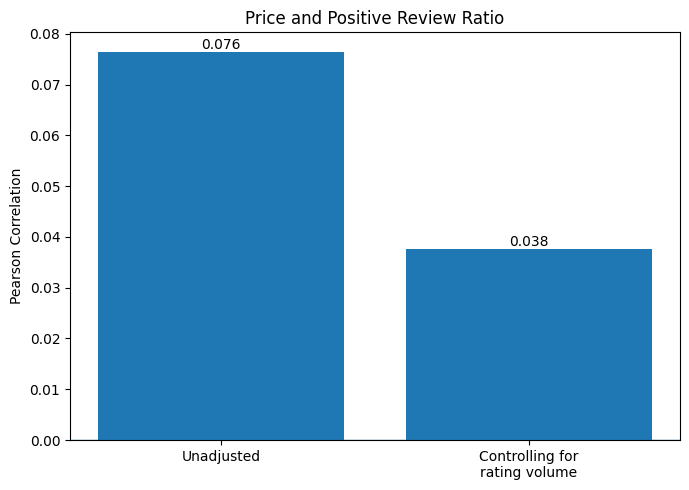

In [2]:
correlation_results = pd.DataFrame(
    {
        "relationship": [
            "Unadjusted",
            "Controlling for\nrating volume",
        ],
        "correlation": [
            overall_r,
            partial_r,
        ],
    }
)


fig, ax = plt.subplots(
    figsize=(7, 5)
)

bars = ax.bar(
    correlation_results["relationship"],
    correlation_results["correlation"],
)

ax.axhline(
    0,
    linewidth=1,
)

ax.set_title(
    "Price and Positive Review Ratio"
)

ax.set_ylabel(
    "Pearson Correlation"
)


for bar, value in zip(
    bars,
    correlation_results["correlation"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.3f}",
        ha="center",
        va="bottom",
    )


plt.tight_layout()
plt.show()

## Conclusion

The overall correlation between game price and positive review ratio is approximately **0.076**, indicating a weak positive relationship.

However, rating volume is associated with both game price and positive review ratio. After accounting for total rating volume, the correlation decreases to approximately **0.038**.

The relationship between higher prices and better user ratings is therefore substantially weaker after accounting for differences in rating volume.
